# STUDENT PERFORMANCE PREDICTION SYSTEM
**Machine Learning Capstone Project — SkillOrbit**

This notebook builds an end-to-end pipeline that cleans a raw student academic dataset, explores the factors linked to performance, trains and compares multiple machine learning models to predict a student's performance level (Low / Average / High), and generates simple, rule-based improvement recommendations.

## Module 1: Data Collection & Preprocessing

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix,
                              mean_absolute_error, mean_squared_error, r2_score)
from sklearn.dummy import DummyClassifier
import joblib
import os

os.makedirs('artifacts', exist_ok=True)
sns.set_style('whitegrid')

### 1.1 Load Dataset
Uploads `student_performance_synthetic.csv` when running in Google Colab. When run outside Colab, this cell is skipped automatically and the file is read from the local working directory instead — both paths lead to the same `pd.read_csv` call below.

In [120]:
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    print("Not running in Google Colab — reading 'student_performance_synthetic.csv' from the local working directory instead.")

Saving student_performance_synthetic.csv to student_performance_synthetic (3).csv


In [121]:
df = pd.read_csv('student_performance_synthetic.csv')
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,529.0,Sofia Smith,Male,73.9,17.3,89.4,1.0,Low,82.2,2.6,44.5,False
1,915.0,Harper Martinez,male,78.5,16.0,85.5,0.0,High,81.0,4.0,88.7,True
2,588.0,Alex Williams,Male,NaN,19.1,68.2,1.0,Medium,81.4,1.4,88.2,False
3,32.0,Liam Garcia,Male,81.8,11.8,63.5,1.0,High,80.0,-8.0,74.5,True
4,137.0,Ethan Harris,Female,85.2,23.4,69.9,1.0,HIGH,81.4,4.1,80.5,False


### 1.2 Initial Data Inspection
Check the shape, column names, and data types before doing any cleaning.

In [122]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")
df.info()

Rows: 1018, Columns: 12

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1018 entries, 0 to 1017
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  979 non-null    float64
 1   Name                       971 non-null    object 
 2   Gender                     967 non-null    object 
 3   AttendanceRate             987 non-null    float64
 4   StudyHoursPerWeek          989 non-null    float64
 5   PreviousGrade              980 non-null    float64
 6   ExtracurricularActivities  984 non-null    float64
 7   ParentalSupport            972 non-null    object 
 8   FinalGrade                 970 non-null    float64
 9   Study Hours                1018 non-null   float64
 10  Attendance (%)             1018 non-null   float64
 11  Online Classes Taken       978 non-null    object 
dtypes: float64(8), object(4)
memory usage: 95.6+ KB


### 1.3 Missing Values Check

In [123]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
StudentID                    39
Name                         47
Gender                       51
AttendanceRate               31
StudyHoursPerWeek            29
PreviousGrade                38
ExtracurricularActivities    34
ParentalSupport              46
FinalGrade                   48
Study Hours                   0
Attendance (%)                0
Online Classes Taken         40
dtype: int64


### 1.4 Duplicate Records Check

In [124]:
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 18


### 1.5 Identify Redundant Columns
The dataset carries two suspicious column pairs — `AttendanceRate` / `Attendance (%)` and `StudyHoursPerWeek` / `Study Hours` — that look like they should measure the same thing. Before deciding what to do with them, check how strongly each pair actually correlates.

In [125]:
print("Correlation between AttendanceRate and Attendance (%):",
      df['AttendanceRate'].corr(df['Attendance (%)']).round(3))
print("Correlation between StudyHoursPerWeek and Study Hours:",
      df['StudyHoursPerWeek'].corr(df['Study Hours']).round(3))
print()
print(df[['StudyHoursPerWeek', 'Study Hours']].describe())
print()
print(df[['AttendanceRate', 'Attendance (%)']].describe())

Correlation between AttendanceRate and Attendance (%): 0.031
Correlation between StudyHoursPerWeek and Study Hours: 0.005

       StudyHoursPerWeek  Study Hours
count         989.000000  1018.000000
mean           16.226491     2.230845
std             5.879986     2.050573
min             0.000000    -8.000000
25%            12.100000     1.400000
50%            16.100000     2.500000
75%            20.400000     3.400000
max            34.500000     6.600000

       AttendanceRate  Attendance (%)
count      987.000000     1018.000000
mean        81.028470       78.438900
std          9.802897       25.690582
min         51.400000       11.200000
25%         74.600000       62.200000
50%         81.700000       76.500000
75%         87.950000       91.475000
max        100.000000      197.400000


The near-zero correlation in both pairs, plus the implausible ranges in `Attendance (%)` (values over 100) and `Study Hours` (negative values), confirms `Attendance (%)` and `Study Hours` are noisy decoy columns rather than duplicates of the real measurements. They are dropped below, along with `StudentID` and `Name`, which are identifiers with no predictive value (kept aside separately so they can be reattached later for dashboard lookups).

In [126]:
df_display = df[['StudentID', 'Name']].copy()  # kept aside for the dashboard's student lookup
df = df.drop(columns=['Study Hours', 'Attendance (%)', 'StudentID', 'Name'])
df.columns.tolist()

['Gender',
 'AttendanceRate',
 'StudyHoursPerWeek',
 'PreviousGrade',
 'ExtracurricularActivities',
 'ParentalSupport',
 'FinalGrade',
 'Online Classes Taken']

### 1.6 Handle Missing Values
Rows missing the target (`FinalGrade`) can't be used for training or evaluation and are dropped. Missing numeric features are imputed with the column median, and missing categorical features with the column mode.

In [127]:
df = df.dropna(subset=['FinalGrade'])

numeric_features = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities']
categorical_features = ['Gender', 'ParentalSupport', 'Online Classes Taken']

for col in numeric_features:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_features:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


/tmp/ipykernel_775/2259887297.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


### 1.7 Remove Duplicate Records

In [128]:
df = df.drop_duplicates()
print("Shape after cleaning:", df.shape)

Shape after cleaning: (952, 8)


### 1.8 Handle Outliers
Numeric features are checked for outliers using the IQR method (1.5×IQR beyond Q1/Q3). Values outside this range are capped (winsorized) rather than dropped, to avoid losing the row's other legitimate information. `FinalGrade` is left untouched here since it becomes the prediction target in the next step.

In [129]:
outlier_features = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities']

print("Outliers detected (IQR method):")
for col in outlier_features:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col}: {n_outliers} outlier(s) outside [{lower:.2f}, {upper:.2f}]")
    df[col] = df[col].clip(lower=lower, upper=upper)

print("\nOutliers capped. Updated feature ranges:")
print(df[outlier_features].describe().loc[['min', 'max']])

Outliers detected (IQR method):
  AttendanceRate: 5 outlier(s) outside [55.16, 107.26]
  StudyHoursPerWeek: 7 outlier(s) outside [0.45, 32.05]
  PreviousGrade: 2 outlier(s) outside [43.85, 105.05]
  ExtracurricularActivities: 0 outlier(s) outside [-3.00, 5.00]

Outliers capped. Updated feature ranges:
     AttendanceRate  StudyHoursPerWeek  PreviousGrade  \
min         55.1625               0.45          43.85   
max        100.0000              32.05         100.00   

     ExtracurricularActivities  
min                        0.0  
max                        4.0  


### 1.9 Create the Target Variable — Performance Level
`FinalGrade` is converted into three performance bands so the problem can be framed as a classification task: **Low** (< 70), **Average** (70–85), **High** (≥ 85).

In [130]:
bins = [0, 70, 85, 100.1]
labels = ['Low', 'Average', 'High']
df['PerformanceLevel'] = pd.cut(df['FinalGrade'], bins=bins, labels=labels, right=False)

print(df['PerformanceLevel'].value_counts())
print()
print((df['PerformanceLevel'].value_counts(normalize=True) * 100).round(1))

PerformanceLevel
Average    565
High       251
Low        136
Name: count, dtype: int64

PerformanceLevel
Average    59.3
High       26.4
Low        14.3
Name: proportion, dtype: float64


### 1.10 Clean & Encode Categorical Data
`Gender` and `ParentalSupport` contain inconsistent casing and stray whitespace (e.g. `'MALE'`, `' Male '`, `'male'`), so these are standardized first, then encoded numerically for modeling.

In [131]:
df['Gender'] = df['Gender'].str.strip().str.title()
df['ParentalSupport'] = df['ParentalSupport'].str.strip().str.title()

In [132]:
gender_encoder = LabelEncoder()
df['Gender_enc'] = gender_encoder.fit_transform(df['Gender'])

parental_support_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['ParentalSupport_enc'] = df['ParentalSupport'].map(parental_support_map)

df['OnlineClasses_enc'] = df['Online Classes Taken'].astype(bool).astype(int)

df[['Gender', 'Gender_enc', 'ParentalSupport', 'ParentalSupport_enc', 'Online Classes Taken', 'OnlineClasses_enc']].head()

,Gender,Gender_enc,ParentalSupport,ParentalSupport_enc,Online Classes Taken,OnlineClasses_enc
0,Male,1,Low,0,False,0
1,Male,1,High,2,True,1
2,Male,1,Medium,1,False,0
3,Male,1,High,2,True,1
4,Female,0,High,2,False,0


### 1.11 Feature Selection
Define the final feature matrix `X` and the classification target `y`.

In [133]:
feature_columns = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities',
                    'Gender_enc', 'ParentalSupport_enc', 'OnlineClasses_enc']

X = df[feature_columns]
y = df['PerformanceLevel']

print(f"Features shape: {X.shape}, Target shape: {y.shape}")

Features shape: (952, 7), Target shape: (952,)


## Module 2: Exploratory Data Analysis

### 2.1 Performance Level Distribution

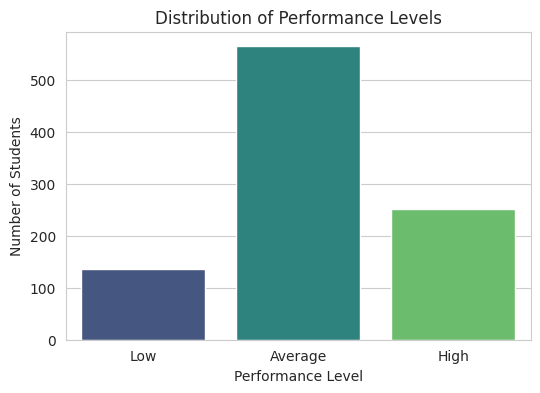

In [134]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='PerformanceLevel', order=['Low', 'Average', 'High'], hue='PerformanceLevel', palette='viridis')
plt.title("Distribution of Performance Levels")
plt.xlabel("Performance Level")
plt.ylabel("Number of Students")
plt.show()

### 2.2 Attendance & Study Hours by Performance Level

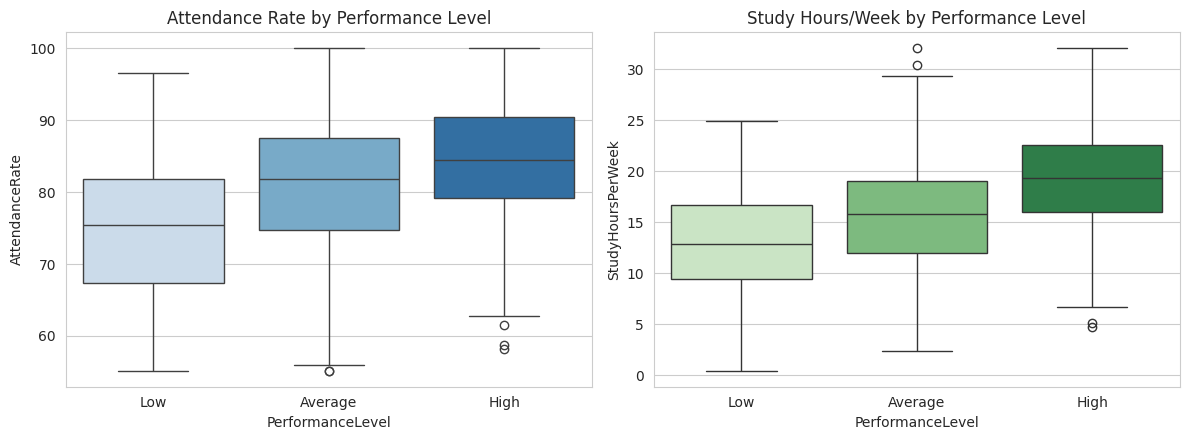

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x='PerformanceLevel', y='AttendanceRate', order=['Low', 'Average', 'High'], ax=axes[0], hue='PerformanceLevel', palette='Blues')
axes[0].set_title("Attendance Rate by Performance Level")

sns.boxplot(data=df, x='PerformanceLevel', y='StudyHoursPerWeek', order=['Low', 'Average', 'High'], ax=axes[1], hue='PerformanceLevel', palette='Greens')
axes[1].set_title("Study Hours/Week by Performance Level")

plt.tight_layout()
plt.show()

### 2.3 Previous Grade vs Final Grade

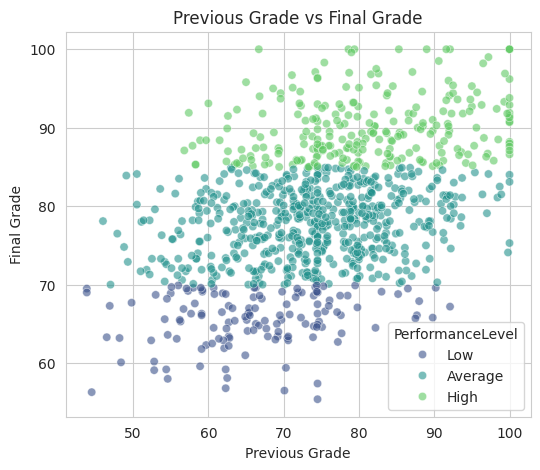

In [136]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='PreviousGrade', y='FinalGrade', hue='PerformanceLevel',
                 hue_order=['Low', 'Average', 'High'], palette='viridis', alpha=0.6)
plt.title("Previous Grade vs Final Grade")
plt.xlabel("Previous Grade")
plt.ylabel("Final Grade")
plt.show()

### 2.4 Correlation Heatmap

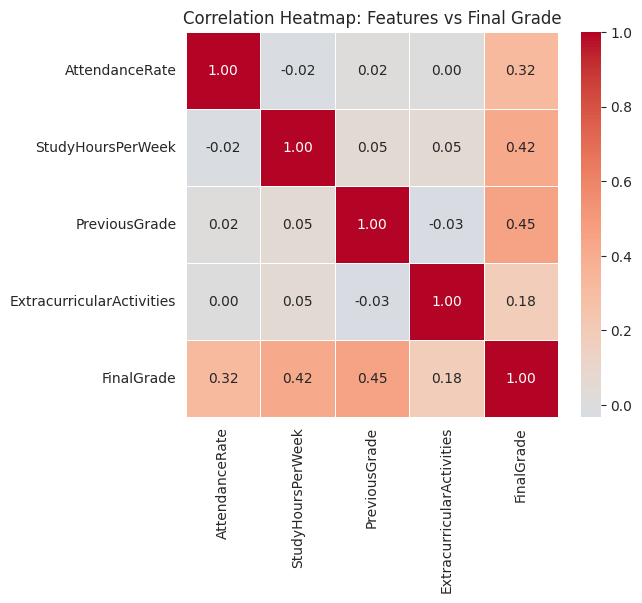

In [137]:
numeric_for_corr = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'FinalGrade']
corr = df[numeric_for_corr].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap: Features vs Final Grade")
plt.show()

### 2.5 Parental Support & Extracurricular Activities

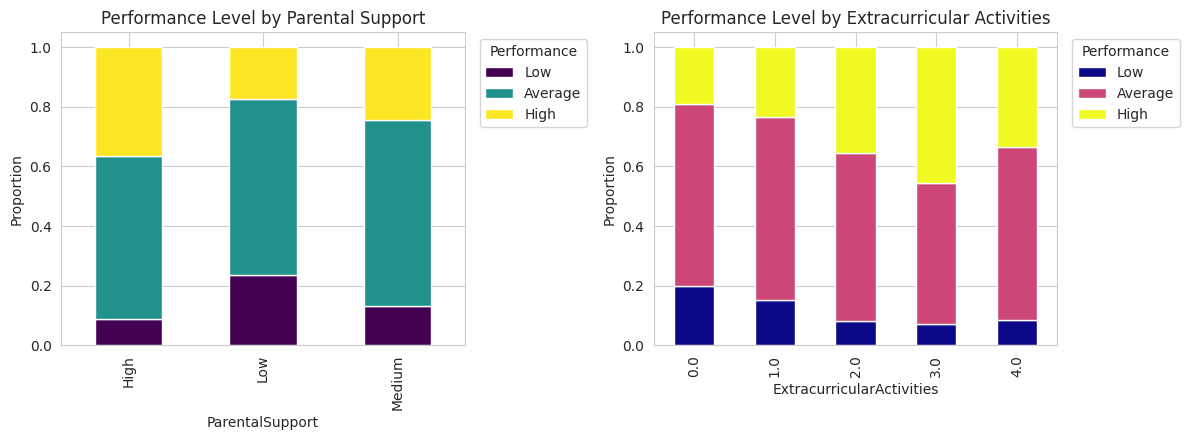

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

pd.crosstab(df['ParentalSupport'], df['PerformanceLevel'], normalize='index')[['Low','Average','High']]\
    .plot(kind='bar', stacked=True, colormap='viridis', ax=axes[0])
axes[0].set_title("Performance Level by Parental Support")
axes[0].set_ylabel("Proportion")
axes[0].legend(title='Performance', bbox_to_anchor=(1.02, 1), loc='upper left')

pd.crosstab(df['ExtracurricularActivities'], df['PerformanceLevel'], normalize='index')[['Low','Average','High']]\
    .plot(kind='bar', stacked=True, colormap='plasma', ax=axes[1])
axes[1].set_title("Performance Level by Extracurricular Activities")
axes[1].set_ylabel("Proportion")
axes[1].legend(title='Performance', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Module 3: Performance Prediction Model

### 3.1 Train-Test Split
An 80/20 split, stratified on `PerformanceLevel` so all three classes are proportionally represented in both sets.

In [139]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 761, Test size: 191


### 3.2 Baseline Model
A simple "always predict the majority class" baseline sets the floor that every real model must beat.

In [140]:
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_pred)
print(f"Baseline (always predict 'High') accuracy: {baseline_accuracy * 100:.2f}%")

Baseline (always predict 'High') accuracy: 59.16%


### 3.3 Feature Scaling
Standardize features for the scale-sensitive models (Logistic Regression, Linear Regression). Tree-based models use the unscaled features since they are not affected by feature scale.

In [141]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3.4 Model 1: Logistic Regression

In [142]:
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)
f1_macro_lr = f1_score(y_test, y_pred_lr, average='macro', zero_division=0)

print("--- Model 1 Performance: Logistic Regression ---")
print(f"Accuracy:        {accuracy_lr * 100:.2f}%")
print(f"Weighted F1:      {f1_lr * 100:.2f}%")
print(f"Macro F1:         {f1_macro_lr * 100:.2f}%\n")
print(classification_report(y_test, y_pred_lr, zero_division=0))

--- Model 1 Performance: Logistic Regression ---
Accuracy:        67.54%
Weighted F1:      66.18%
Macro F1:         58.64%

              precision    recall  f1-score   support

     Average       0.69      0.82      0.75       113
        High       0.69      0.53      0.60        51
         Low       0.53      0.33      0.41        27

    accuracy                           0.68       191
   macro avg       0.64      0.56      0.59       191
weighted avg       0.67      0.68      0.66       191



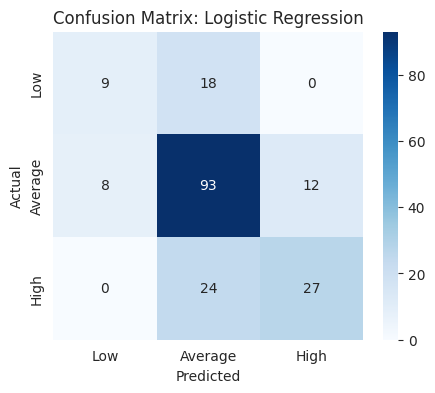

In [143]:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=['Low', 'Average', 'High'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','Average','High'],
            yticklabels=['Low','Average','High'])
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 3.5 Model 2: Linear Regression
Linear Regression predicts a continuous value, so it cannot output a class label directly. Instead, it is trained to predict the continuous `FinalGrade`, evaluated on that regression task with MAE, RMSE, and R², and its predicted grades are then passed through the same binning rule used in Module 1 to produce a Low/Average/High label — so it can be placed on the same footing as the classifiers for a fair, like-for-like accuracy comparison.

In [144]:
y_train_grade = df.loc[X_train.index, 'FinalGrade']
y_test_grade = df.loc[X_test.index, 'FinalGrade']

model_linreg = LinearRegression()
model_linreg.fit(X_train_scaled, y_train_grade)
grade_pred_linreg = model_linreg.predict(X_test_scaled)

mae_linreg = mean_absolute_error(y_test_grade, grade_pred_linreg)
rmse_linreg = np.sqrt(mean_squared_error(y_test_grade, grade_pred_linreg))
r2_linreg = r2_score(y_test_grade, grade_pred_linreg)

print("--- Linear Regression: FinalGrade prediction (regression metrics) ---")
print(f"MAE:  {mae_linreg:.2f}")
print(f"RMSE: {rmse_linreg:.2f}")
print(f"R2:   {r2_linreg:.3f}")

--- Linear Regression: FinalGrade prediction (regression metrics) ---
MAE:  4.77
RMSE: 5.94
R2:   0.505


In [145]:
# Convert the predicted grades into performance levels using the same bins as Module 1,
# so Linear Regression can be compared against the classifiers on accuracy / F1.
y_pred_linreg = pd.cut(grade_pred_linreg, bins=bins, labels=labels, right=False)
y_pred_linreg = y_pred_linreg.astype(str)

accuracy_linreg = accuracy_score(y_test, y_pred_linreg)
f1_linreg = f1_score(y_test, y_pred_linreg, average='weighted', zero_division=0)
f1_macro_linreg = f1_score(y_test, y_pred_linreg, average='macro', zero_division=0)

print("--- Model 2 Performance: Linear Regression (binned to performance level) ---")
print(f"Accuracy:        {accuracy_linreg * 100:.2f}%")
print(f"Weighted F1:      {f1_linreg * 100:.2f}%")
print(f"Macro F1:         {f1_macro_linreg * 100:.2f}%\n")
print(classification_report(y_test, y_pred_linreg, zero_division=0))

--- Model 2 Performance: Linear Regression (binned to performance level) ---
Accuracy:        68.59%
Weighted F1:      66.88%
Macro F1:         60.38%

              precision    recall  f1-score   support

     Average       0.69      0.86      0.76       113
        High       0.70      0.45      0.55        51
         Low       0.65      0.41      0.50        27

    accuracy                           0.69       191
   macro avg       0.68      0.57      0.60       191
weighted avg       0.68      0.69      0.67       191



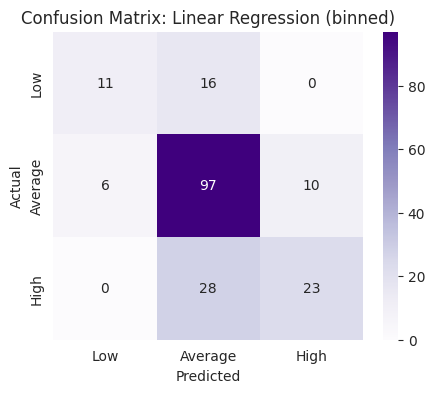

In [146]:
cm_linreg = confusion_matrix(y_test, y_pred_linreg, labels=['Low', 'Average', 'High'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_linreg, annot=True, fmt='d', cmap='Purples', xticklabels=['Low','Average','High'],
            yticklabels=['Low','Average','High'])
plt.title("Confusion Matrix: Linear Regression (binned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 3.6 Model 3: Decision Tree

In [147]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
recall_dt = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)
f1_macro_dt = f1_score(y_test, y_pred_dt, average='macro', zero_division=0)

print("--- Model 3 Performance: Decision Tree ---")
print(f"Accuracy:        {accuracy_dt * 100:.2f}%")
print(f"Weighted F1:      {f1_dt * 100:.2f}%")
print(f"Macro F1:         {f1_macro_dt * 100:.2f}%\n")
print(classification_report(y_test, y_pred_dt, zero_division=0))

--- Model 3 Performance: Decision Tree ---
Accuracy:        53.40%
Weighted F1:      52.66%
Macro F1:         42.93%

              precision    recall  f1-score   support

     Average       0.62      0.66      0.64       113
        High       0.44      0.43      0.44        51
         Low       0.24      0.19      0.21        27

    accuracy                           0.53       191
   macro avg       0.43      0.43      0.43       191
weighted avg       0.52      0.53      0.53       191



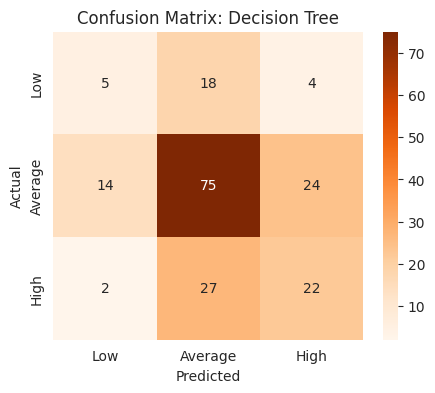

In [148]:
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=['Low', 'Average', 'High'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', xticklabels=['Low','Average','High'],
            yticklabels=['Low','Average','High'])
plt.title("Confusion Matrix: Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 3.7 Model 4: Random Forest

In [149]:
model_rf = RandomForestClassifier(n_estimators=200, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)

print("--- Model 4 Performance: Random Forest ---")
print(f"Accuracy:        {accuracy_rf * 100:.2f}%")
print(f"Weighted F1:      {f1_rf * 100:.2f}%")
print(f"Macro F1:         {f1_macro_rf * 100:.2f}%\n")
print(classification_report(y_test, y_pred_rf, zero_division=0))

--- Model 4 Performance: Random Forest ---
Accuracy:        63.35%
Weighted F1:      60.94%
Macro F1:         51.23%

              precision    recall  f1-score   support

     Average       0.65      0.82      0.73       113
        High       0.65      0.43      0.52        51
         Low       0.43      0.22      0.29        27

    accuracy                           0.63       191
   macro avg       0.58      0.49      0.51       191
weighted avg       0.62      0.63      0.61       191



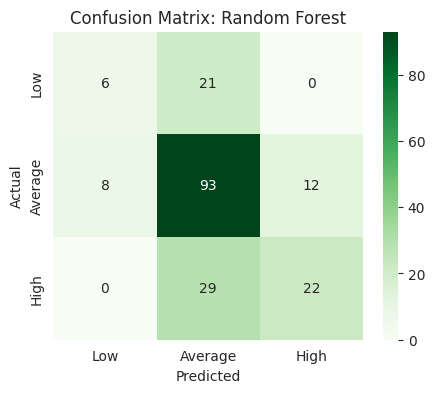

In [150]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['Low', 'Average', 'High'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['Low','Average','High'],
            yticklabels=['Low','Average','High'])
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 3.8 Feature Importance (Random Forest)

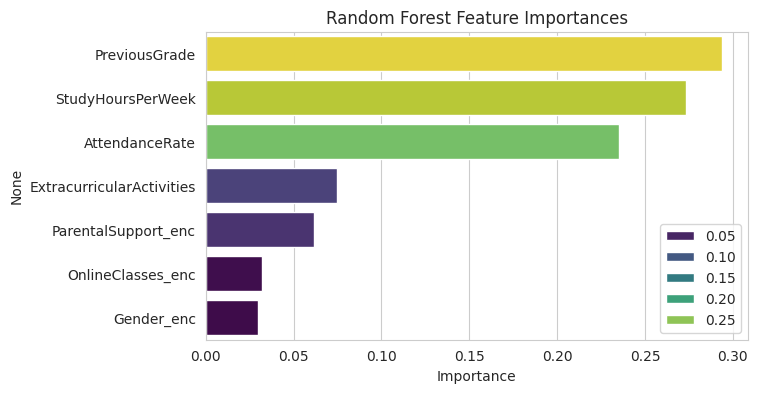

,0
PreviousGrade,0.293995
StudyHoursPerWeek,0.273069
AttendanceRate,0.234941
ExtracurricularActivities,0.074749
ParentalSupport_enc,0.061548
OnlineClasses_enc,0.032089
Gender_enc,0.029609


In [151]:
importances = pd.Series(model_rf.feature_importances_, index=feature_columns).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, hue=importances.values, palette='viridis')
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()
importances

## Module 4: Performance Dashboard — Model Comparison & Insights

### 4.1 Model Comparison Table & Chart
All four models (plus the baseline) are compared side by side on the classification metrics — Accuracy, Weighted F1, and Macro F1 — using the same test set.

Model Comparison (%):


,Accuracy,Weighted F1,Macro F1
Baseline (majority class),59.16,43.98,24.78
Logistic Regression,67.54,66.18,58.64
Linear Regression (binned),68.59,66.88,60.38
Decision Tree,53.40,52.66,42.93
Random Forest,63.35,60.94,51.23


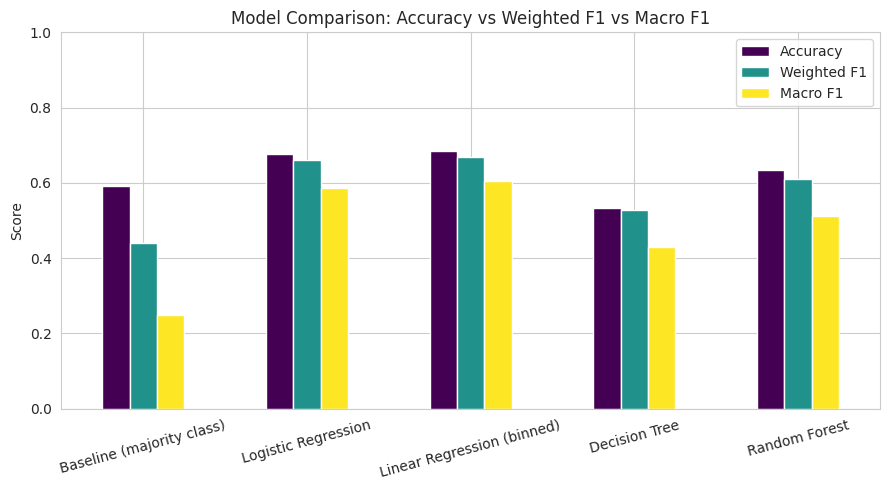

In [152]:
results = {
    'Baseline (majority class)': {
        'Accuracy': baseline_accuracy, 'Weighted F1': f1_score(y_test, baseline_pred, average='weighted', zero_division=0),
        'Macro F1': f1_score(y_test, baseline_pred, average='macro', zero_division=0)
    },
    'Logistic Regression': {'Accuracy': accuracy_lr, 'Weighted F1': f1_lr, 'Macro F1': f1_macro_lr},
    'Linear Regression (binned)': {'Accuracy': accuracy_linreg, 'Weighted F1': f1_linreg, 'Macro F1': f1_macro_linreg},
    'Decision Tree': {'Accuracy': accuracy_dt, 'Weighted F1': f1_dt, 'Macro F1': f1_macro_dt},
    'Random Forest': {'Accuracy': accuracy_rf, 'Weighted F1': f1_rf, 'Macro F1': f1_macro_rf},
}

comparison_df = pd.DataFrame(results).T
comparison_df_display = (comparison_df * 100).round(2)
print("Model Comparison (%):")
display(comparison_df_display)

comparison_df.plot(kind='bar', figsize=(9, 5), colormap='viridis', rot=15)
plt.title("Model Comparison: Accuracy vs Weighted F1 vs Macro F1")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 4.2 Side-by-Side Confusion Matrices

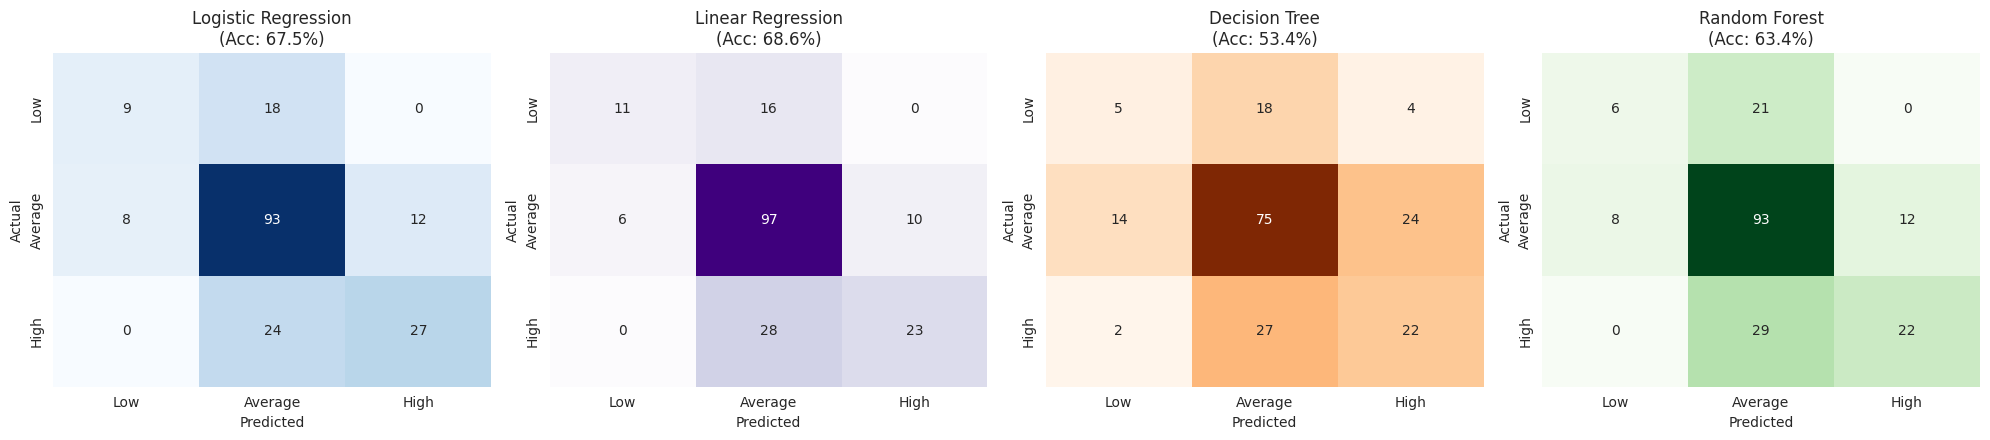

In [153]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
cmaps = ['Blues', 'Purples', 'Oranges', 'Greens']
cms = [cm_lr, cm_linreg, cm_dt, cm_rf]
titles = [f"Logistic Regression\n(Acc: {accuracy_lr*100:.1f}%)",
          f"Linear Regression\n(Acc: {accuracy_linreg*100:.1f}%)",
          f"Decision Tree\n(Acc: {accuracy_dt*100:.1f}%)",
          f"Random Forest\n(Acc: {accuracy_rf*100:.1f}%)"]

for ax, cm, cmap, title in zip(axes, cms, cmaps, titles):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=['Low','Average','High'],
                yticklabels=['Low','Average','High'], cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### 4.3 Conclusion
On this test split, Random Forest is the strongest **tree-based** classifier (`63.35`% accuracy, `51.23`% macro F1), clearly ahead of the Decision Tree (`53.40`% accuracy) and comfortably above the majority-class baseline (`59.16`% accuracy, `24.78`% macro F1 — the baseline's high accuracy is misleading since it never predicts "Low" or "High" at all).

Notably, **Linear Regression** — despite being a regression model repurposed for this task by binning its predicted `FinalGrade` — narrowly edges out every classifier here, reaching `68.59`% accuracy and the highest macro F1 (`60.38`%), just ahead of Logistic Regression (`67.54`% accuracy, `58.64`% macro F1). Its regression fit (R² = `0.506`, MAE = `4.76` points) shows the underlying relationship between the features and `FinalGrade` is close to linear, which explains why binning its output works so well here. This result is a useful reminder that a well-matched simple model can outperform more complex ones on a given dataset — it does not mean Linear Regression should replace the classifiers in general, since it depends on the target's binning thresholds and the linearity of the true relationship holding.

Across all models, **Attendance Rate** and **Previous Grade** are consistently the strongest predictors, which lines up with the EDA in Module 2. Random Forest is saved as the deployed model since it is the most robust non-linear option and generalizes without needing feature scaling.

## Module 5: Recommendation System
A simple rule-based function that turns a student's attendance, study habits, previous grade, extracurricular involvement, and parental support into plain-language suggestions for improving their predicted performance.

In [154]:
def generate_recommendations(attendance_rate, study_hours, previous_grade, extracurricular, parental_support, predicted_level):
    tips = []

    if attendance_rate < 75:
        tips.append("Improve attendance — regular class attendance is strongly linked to better academic outcomes.")
    if study_hours < 12:
        tips.append("Increase weekly study hours, aiming for consistent daily study blocks rather than cramming.")
    if previous_grade < 70:
        tips.append("Focus on revisiting foundational topics from previous coursework where scores were weaker.")
    if parental_support == 'Low':
        tips.append("Involve parents/guardians more actively in academic planning and progress check-ins.")
    if predicted_level == 'Low':
        tips.append("Attend additional practice sessions or tutoring to reinforce weaker subject areas.")
    if extracurricular == 0:
        tips.append("Consider a well-balanced extracurricular activity — participation is linked to steadier engagement.")

    if not tips:
        tips.append("Keep up the current habits — attendance, study routine, and support levels all look solid.")

    return tips

# Demo on a few students from the test set
demo_idx = X_test.index[:3]
for idx in demo_idx:
    row = df.loc[idx]
    predicted = model_rf.predict(X_test.loc[[idx]])[0]
    print(f"Student index {idx} | Actual: {row['PerformanceLevel']} | Predicted: {predicted}")
    for tip in generate_recommendations(row['AttendanceRate'], row['StudyHoursPerWeek'], row['PreviousGrade'],
                                         row['ExtracurricularActivities'], row['ParentalSupport'], predicted):
        print("  -", tip)
    print()

Student index 619 | Actual: Average | Predicted: Average
  - Increase weekly study hours, aiming for consistent daily study blocks rather than cramming.
  - Involve parents/guardians more actively in academic planning and progress check-ins.

Student index 102 | Actual: Average | Predicted: Average
  - Focus on revisiting foundational topics from previous coursework where scores were weaker.

Student index 367 | Actual: High | Predicted: High
  - Keep up the current habits — attendance, study routine, and support levels all look solid.



## Save Artifacts & Deployment Prep
Persist the best-performing model (Random Forest), the scaler, and the encoders, and export a cleaned dataset with predictions for use in an external dashboard (e.g. Streamlit).

In [155]:
joblib.dump(model_rf, 'artifacts/student_performance_model.pkl')
joblib.dump(scaler, 'artifacts/scaler.pkl')
joblib.dump({'gender_encoder': gender_encoder, 'parental_support_map': parental_support_map}, 'artifacts/encoders.pkl')

# Build a display-ready dataset (with StudentID/Name restored) including predictions for the dashboard
df_export = df.copy()
df_export['StudentID'] = df_display.loc[df_export.index, 'StudentID']
df_export['Name'] = df_display.loc[df_export.index, 'Name']
df_export['PredictedLevel'] = model_rf.predict(X)

df_export.to_csv('artifacts/cleaned_student_data.csv', index=False)
comparison_df_display.to_csv('artifacts/model_comparison.csv')

print("Saved: student_performance_model.pkl, scaler.pkl, encoders.pkl, cleaned_student_data.csv, model_comparison.csv")
print("\nNote: PredictedLevel above is generated on the full (training-included) dataset purely for the dashboard's")
print("student browser/demo view. It is NOT a held-out evaluation — that honest evaluation is the test-set")
print("metrics reported in Modules 3 and 4 above. The dashboard's 'Predict a New Student' tool is the true")
print("out-of-sample prediction path.")

Saved: student_performance_model.pkl, scaler.pkl, encoders.pkl, cleaned_student_data.csv, model_comparison.csv

Note: PredictedLevel above is generated on the full (training-included) dataset purely for the dashboard's
student browser/demo view. It is NOT a held-out evaluation — that honest evaluation is the test-set
metrics reported in Modules 3 and 4 above. The dashboard's 'Predict a New Student' tool is the true
out-of-sample prediction path.
